In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("./dataCSV/height-weight.csv")

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


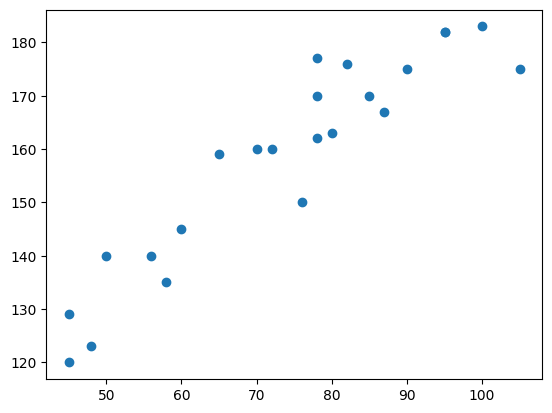

In [7]:
plt.scatter(df["Weight"], df["Height"])
plt.show()

## Steps of ML model : 
1. Dataset
2. Train test split of dataset
3. Standardize the data
4. Train the model with apt ML algorithm

In [34]:
from sklearn.model_selection import train_test_split
X = df[["Weight"]]
y = df[["Height"]]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [28]:
X.shape

(23, 1)

In [29]:
X_train.shape

(18, 1)

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [48]:
model.coef_

array([[17.03440872]])

In [49]:
model.intercept_

array([157.5])

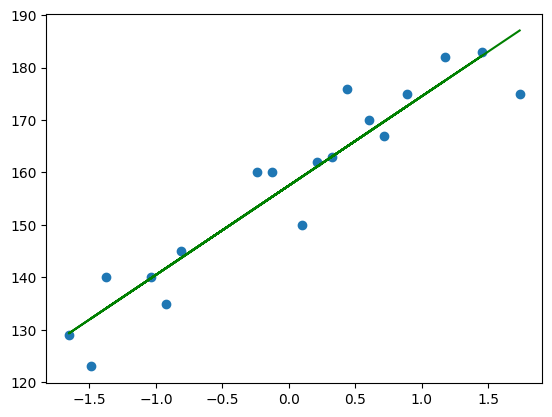

In [62]:
plt.scatter(X_train,y_train)
plt.plot(X_train, model.predict(X_train), c="g")

In [63]:
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
print("r2 score : ", r2_score(y_test, y_pred))
print("mae : ", mean_absolute_error(y_test, y_pred))
print("mse : ", mean_squared_error(y_test, y_pred))
print("rmse : ", root_mean_squared_error(y_test, y_pred))

r2 score :  0.776986986042344
mae :  9.822657814519232
mse :  109.77592599051664
rmse :  10.477400726827081


## Assumptions for training a nice model

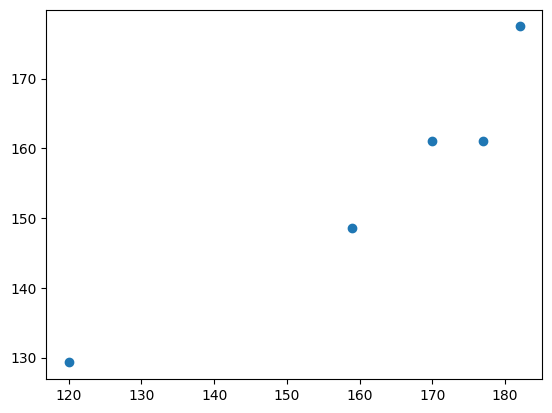

In [65]:
plt.scatter(y_test, y_pred)
## if it is a linear distribution => good model here it is a good model

In [69]:
residuals = y_test - y_pred

In [71]:
print(residuals)

       Height
15  15.915329
9    8.915329
0   -9.304156
8    4.543549
17  10.434926


/var/folders/v9/w1j71nzs1hxgws4nxlscb6540000gn/T/ipykernel_27154/3301513583.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde = True)


<Axes: ylabel='Density'>

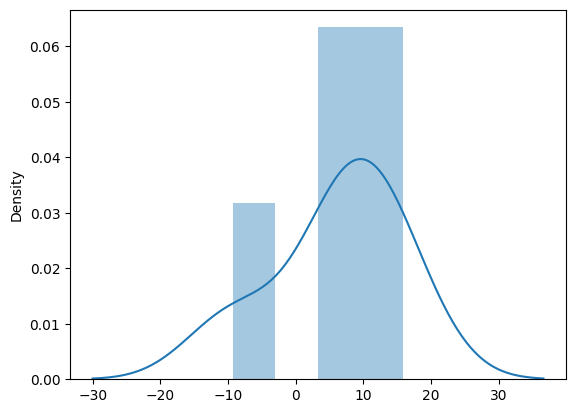

In [73]:
import seaborn as sns
sns.distplot(residuals, kde = True)
## if it is a normal distribution => good model here it is a good model

In [74]:
print(residuals.mean())

Height    6.100995
dtype: float64


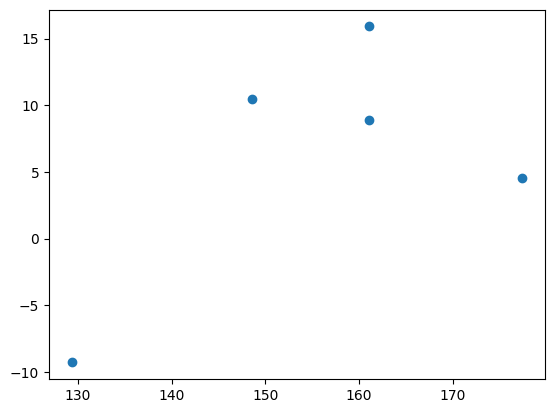

In [75]:
plt.scatter(y_pred, residuals)
## if it is a uniform distribution => good model here it is a good model